In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw

In [2]:
method = 'pearson'
region = 'Italy'

In [3]:
# dir_base = os.path.join('..','..','output','autocorr','data')
dir_base = os.path.join('..','..','output','autocorr','test')
dir_sat = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')

In [4]:
lon_min, lon_max, lat_min, lat_max, area, toll = 10.5, 13.5, 44.5, 47, 'Veneto', 0.002

## Number of pixel 2 and Neighborhood 5x5

In [5]:
# IMERG
input_file = os.path.join(dir_base,f'{region}_IMERG_Npix_2_mar_{method}.csv')
IMERG_2 = pd.read_csv(input_file)

# CMORPH
input_file = os.path.join(dir_base,f'{region}_CMORPH_Npix_2_mar_{method}.csv')
CMORPH_2 = pd.read_csv(input_file)

# MSWEP
input_file = os.path.join(dir_base,f'{region}_MSWEP_Npix_2_mar_{method}.csv')
MSWEP_2 = pd.read_csv(input_file)

# ERA5
input_file = os.path.join(dir_base,f'{region}_ERA5_Npix_2_mar_{method}.csv')
ERA5_2 = pd.read_csv(input_file)

# GSMaP
input_file = os.path.join(dir_base,f'{region}_GSMaP_Npix_2_mar_{method}.csv')
GSMaP_2 = pd.read_csv(input_file)	

# CHIRPS
input_file = os.path.join(dir_base,f'{region}_CHIRPS_Npix_2_mar_{method}.csv')
CHIRPS_2 = pd.read_csv(input_file)	

In [6]:
dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_IMERG_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
IMERG_dist_2 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_CMORPH_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
CMORPH_dist_2 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_MSWEP_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
MSWEP_dist_2 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_ERA5_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
ERA5_dist_2 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_GSMaP_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
GSMaP_dist_2 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','test',f'{region}_CHIRPS_Npix_2_dist.csv')
dist = pd.read_csv(dir_out)
CHIRPS_dist_2 = dist.dist.values

Export figure to: ../../figures/autocorr/Italy_autocorr_Npix_2_mar_pearson.png


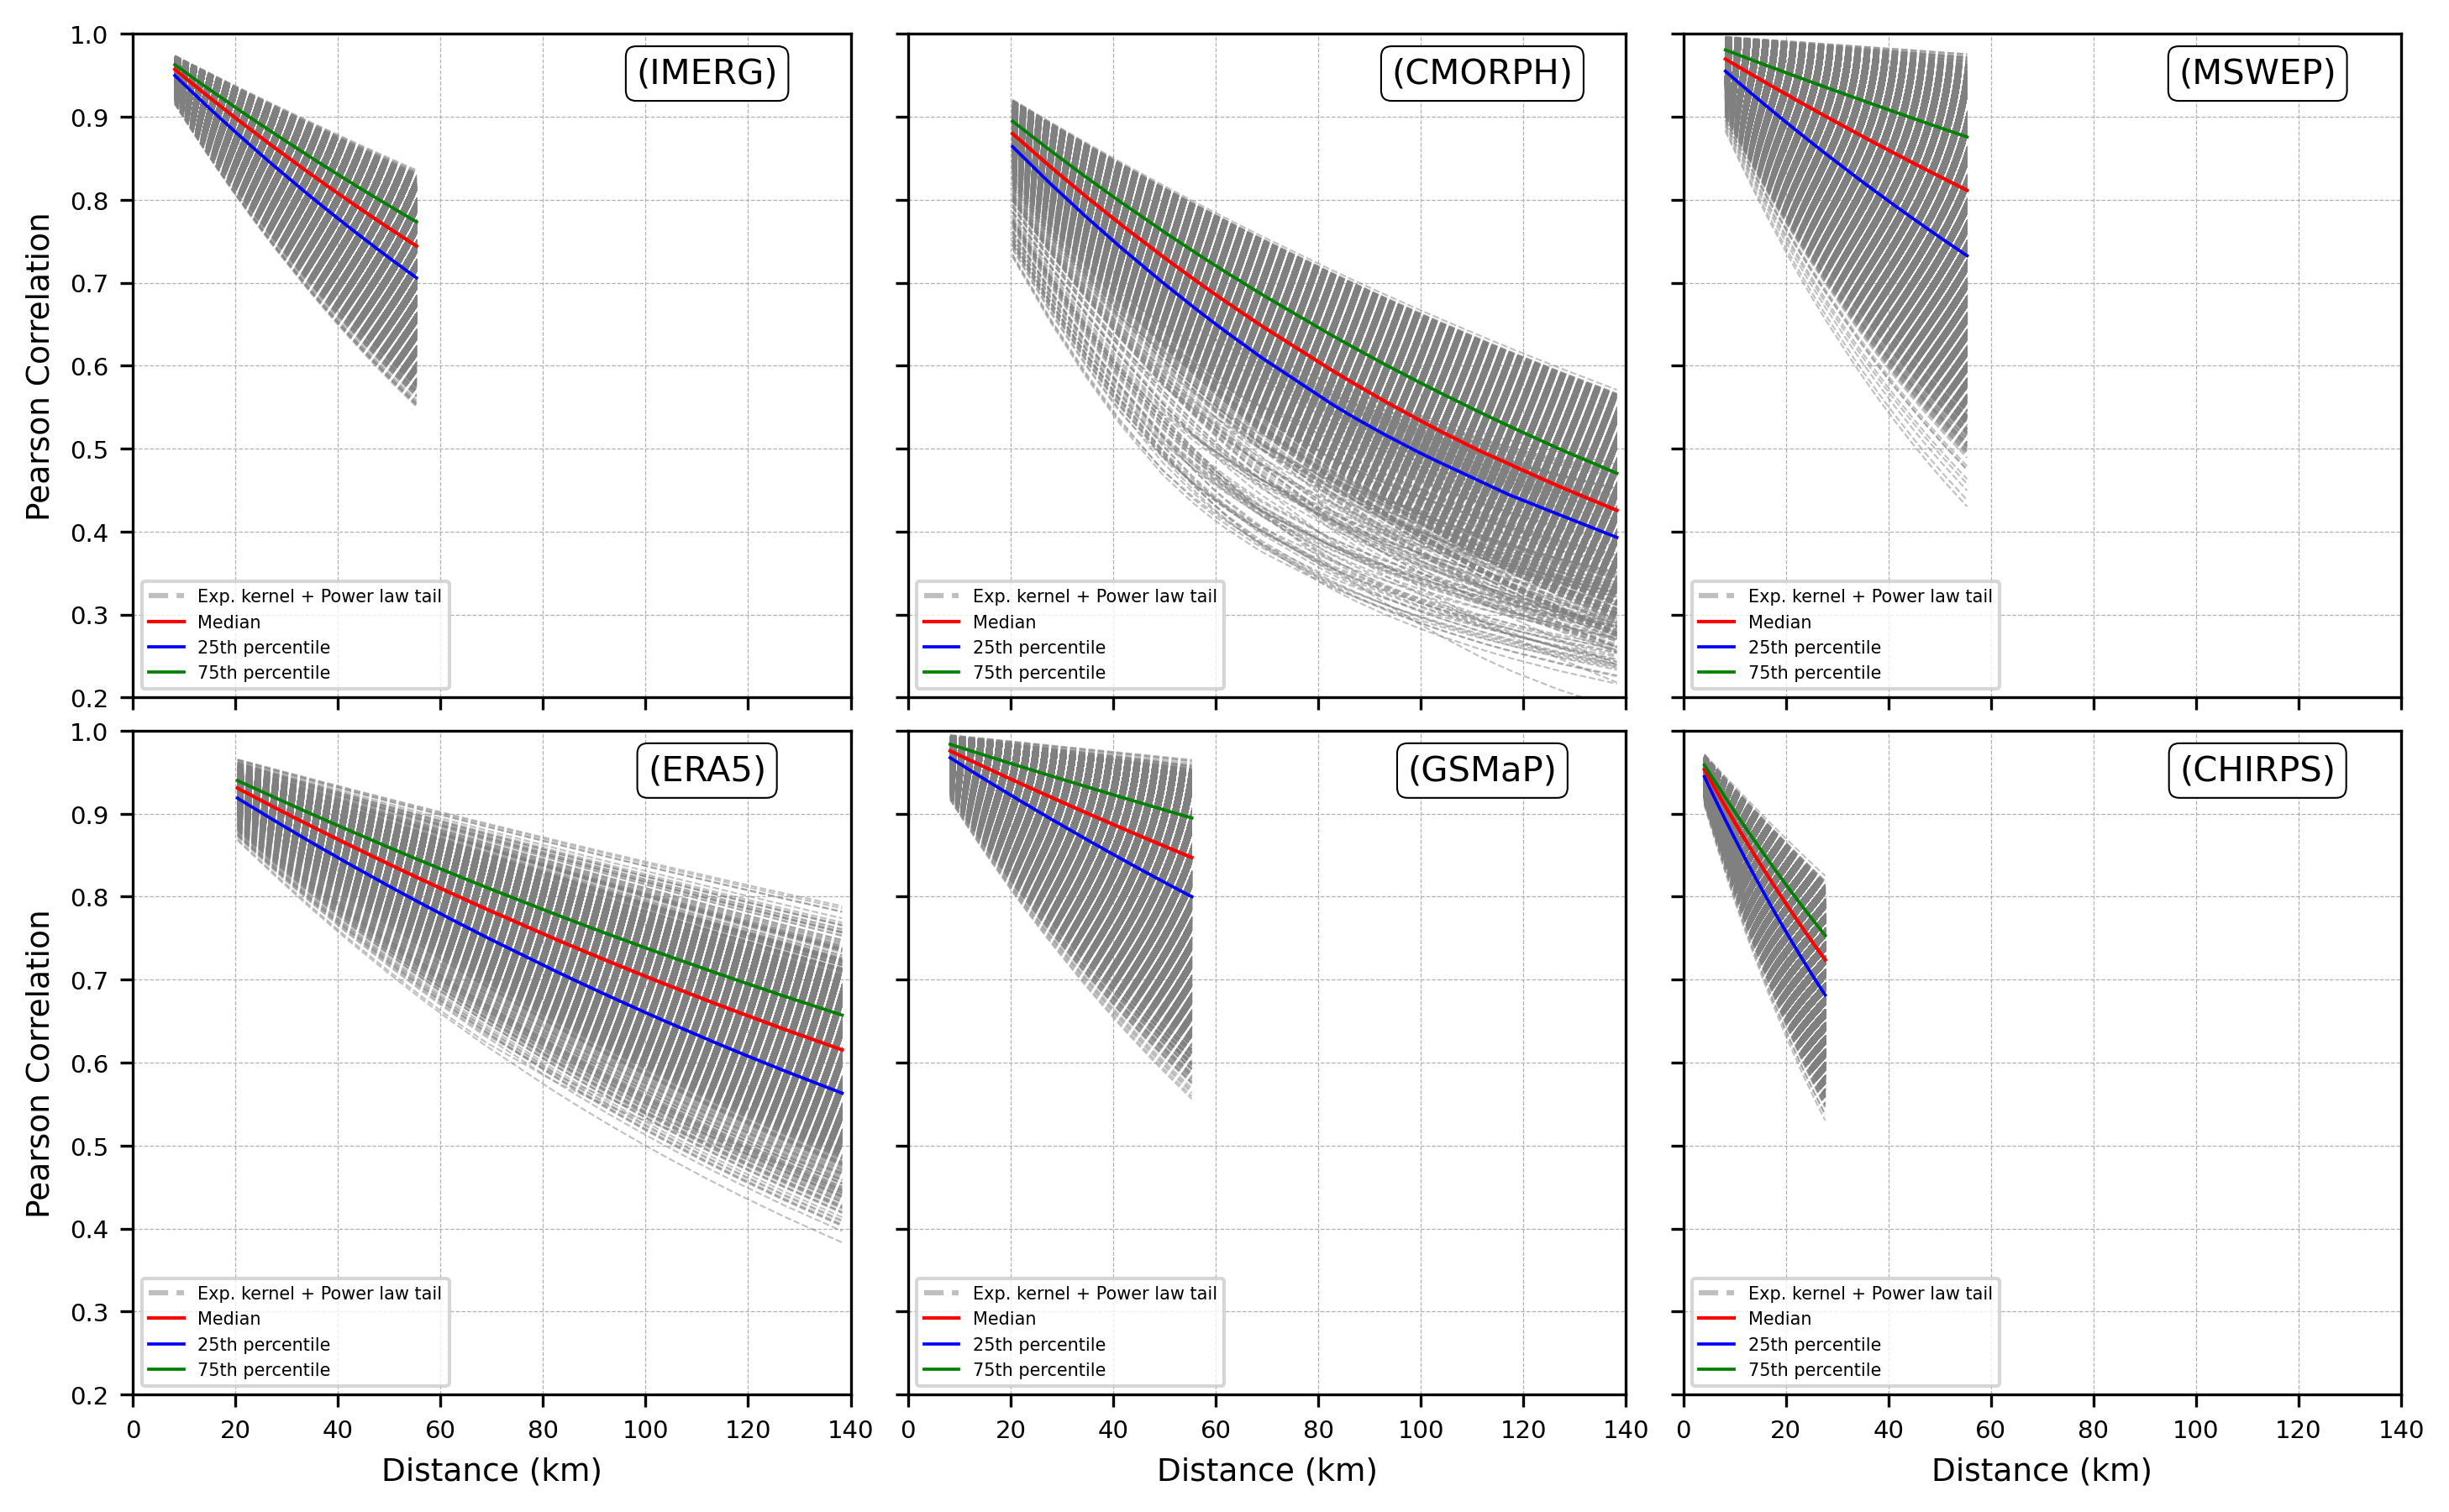

In [7]:
positions = [(r, c) for r in range(2) for c in range(3)]
# labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
labels = ['(IMERG)','(CMORPH)','(MSWEP)','(ERA5)','(GSMaP)','(CHIRPS)']

fig = plt.figure(figsize=(10, 6), dpi=300)
gs = gridspec.GridSpec(2, 3)

# ==========================================================================================================
axes = {}
pos = 0
for pos, (nrow, ncol) in enumerate(positions):
    
    ax = fig.add_subplot(gs[nrow, ncol])

    if ncol == 1 or ncol ==2:
        ax.set_yticklabels([])

    if nrow == 0:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Distance (km)',fontsize=9)

    if ncol == 0:
        ax.set_ylabel('Pearson Correlation',fontsize=9)

    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.grid(linewidth=0.3, linestyle='--')

    ax.text(0.8, 0.94, labels[pos], #0.93
        fontsize=10, ha='center', va='center',
        transform=ax.transAxes, zorder=20,
        bbox=dict(boxstyle="round,pad=0.3",  
            facecolor="white", 
            alpha=1,
            edgecolor="black",
            linewidth=0.5))

    axes[(nrow, ncol)] = ax

# ==========================================================================================================
axes[(0, 0)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(IMERG_2)):
    y_vals = DOWN_raw.epl_fun(IMERG_dist_2, IMERG_2['epsilon'].iloc[nn], IMERG_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 0)].plot(IMERG_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

IMERG_curvas2 = np.array(todas_las_curvas)

median = np.median(IMERG_curvas2, axis=0)
p25 = np.percentile(IMERG_curvas2, 25, axis=0)
p75 = np.percentile(IMERG_curvas2, 75, axis=0)

axes[(0, 0)].plot(IMERG_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 0)].plot(IMERG_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 0)].plot(IMERG_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 0)].set_xlim(0,140)
axes[(0, 0)].set_ylim(0.2,1)
axes[(0, 0)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(0, 1)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(CMORPH_2)):
    y_vals = DOWN_raw.epl_fun(CMORPH_dist_2, CMORPH_2['epsilon'].iloc[nn], CMORPH_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 1)].plot(CMORPH_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

CMORPH_curvas2 = np.array(todas_las_curvas)

median = np.median(CMORPH_curvas2, axis=0)
p25 = np.percentile(CMORPH_curvas2, 25, axis=0)
p75 = np.percentile(CMORPH_curvas2, 75, axis=0)

axes[(0, 1)].plot(CMORPH_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 1)].plot(CMORPH_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 1)].plot(CMORPH_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 1)].set_xlim(0,140)
axes[(0, 1)].set_ylim(0.2,1)
axes[(0, 1)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(0, 2)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(MSWEP_2)):
    y_vals = DOWN_raw.epl_fun(MSWEP_dist_2, MSWEP_2['epsilon'].iloc[nn], MSWEP_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 2)].plot(MSWEP_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

MSWEP_curvas2 = np.array(todas_las_curvas)

median = np.median(MSWEP_curvas2, axis=0)
p25 = np.percentile(MSWEP_curvas2, 25, axis=0)
p75 = np.percentile(MSWEP_curvas2, 75, axis=0)

axes[(0, 2)].plot(MSWEP_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 2)].plot(MSWEP_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 2)].plot(MSWEP_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 2)].set_xlim(0,140)
axes[(0, 2)].set_ylim(0.2,1)
axes[(0, 2)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 0)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(ERA5_2)):
    y_vals = DOWN_raw.epl_fun(ERA5_dist_2, ERA5_2['epsilon'].iloc[nn], ERA5_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 0)].plot(ERA5_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

ERA5_curvas2 = np.array(todas_las_curvas)

median = np.median(ERA5_curvas2, axis=0)
p25 = np.percentile(ERA5_curvas2, 25, axis=0)
p75 = np.percentile(ERA5_curvas2, 75, axis=0)

axes[(1, 0)].plot(ERA5_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 0)].plot(ERA5_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 0)].plot(ERA5_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 0)].set_xlim(0,140)
axes[(1, 0)].set_ylim(0.2,1)
axes[(1, 0)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 1)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(GSMaP_2)):
    y_vals = DOWN_raw.epl_fun(GSMaP_dist_2, GSMaP_2['epsilon'].iloc[nn], GSMaP_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 1)].plot(GSMaP_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

GSMaP_curvas2 = np.array(todas_las_curvas)

median = np.median(GSMaP_curvas2, axis=0)
p25 = np.percentile(GSMaP_curvas2, 25, axis=0)
p75 = np.percentile(GSMaP_curvas2, 75, axis=0)

axes[(1, 1)].plot(GSMaP_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 1)].plot(GSMaP_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 1)].plot(GSMaP_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 1)].set_xlim(0,140)
axes[(1, 1)].set_ylim(0.2,1)
axes[(1, 1)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 2)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(CHIRPS_2)):
    y_vals = DOWN_raw.epl_fun(CHIRPS_dist_2, CHIRPS_2['epsilon'].iloc[nn], CHIRPS_2['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 2)].plot(CHIRPS_dist_2, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

CHIRPS_curvas2 = np.array(todas_las_curvas)

median = np.median(CHIRPS_curvas2, axis=0)
p25 = np.percentile(CHIRPS_curvas2, 25, axis=0)
p75 = np.percentile(CHIRPS_curvas2, 75, axis=0)

axes[(1, 2)].plot(CHIRPS_dist_2, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 2)].plot(CHIRPS_dist_2, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 2)].plot(CHIRPS_dist_2, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 2)].set_xlim(0,140)
axes[(1, 2)].set_ylim(0.2,1)
axes[(1, 2)].legend(fontsize=5,loc=3)

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.05)

salida = os.path.join('..','..','figures','autocorr',f'{region}_autocorr_Npix_2_mar_{method}.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

In [8]:
sys.exit()

SystemExit: 

/home/arturo/anaconda3/envs/AXE/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Number of pixel 3 and Neighborhood 7x7

In [ ]:
# IMERG
input_file = os.path.join(dir_base,f'IMERG_Npix_3_mar_{method}.csv')
IMERG_3 = pd.read_csv(input_file)

# CMORPH
input_file = os.path.join(dir_base,f'CMORPH_Npix_3_mar_{method}.csv')
CMORPH_3 = pd.read_csv(input_file)

# MSWEP
input_file = os.path.join(dir_base,f'MSWEP_Npix_3_mar_{method}.csv')
MSWEP_3 = pd.read_csv(input_file)

# ERA5
input_file = os.path.join(dir_base,f'ERA5_Npix_3_mar_{method}.csv')
ERA5_3 = pd.read_csv(input_file)

# GSMaP
input_file = os.path.join(dir_base,f'GSMaP_Npix_3_mar_{method}.csv')
GSMaP_3 = pd.read_csv(input_file)	

# CHIRPS
input_file = os.path.join(dir_base,f'CHIRPS_Npix_3_mar_{method}.csv')
CHIRPS_3 = pd.read_csv(input_file)	

In [ ]:
dir_out = os.path.join('..','..','output','autocorr','dist',f'IMERG_Npix_3.csv')
dist = pd.read_csv(dir_out)
IMERG_dist_3 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','dist',f'CMORPH_Npix_3.csv')
dist = pd.read_csv(dir_out)
CMORPH_dist_3 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','dist',f'MSWEP_Npix_3.csv')
dist = pd.read_csv(dir_out)
MSWEP_dist_3 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','dist',f'ERA5_Npix_3.csv')
dist = pd.read_csv(dir_out)
ERA5_dist_3 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','dist',f'GSMaP_Npix_3.csv')
dist = pd.read_csv(dir_out)
GSMaP_dist_3 = dist.dist.values

dir_out = os.path.join('..','..','output','autocorr','dist',f'CHIRPS_Npix_3.csv')
dist = pd.read_csv(dir_out)
CHIRPS_dist_3 = dist.dist.values

Export figure to: ../../figures/autocorr/autocorr_Npix_3_mar_pearson.png


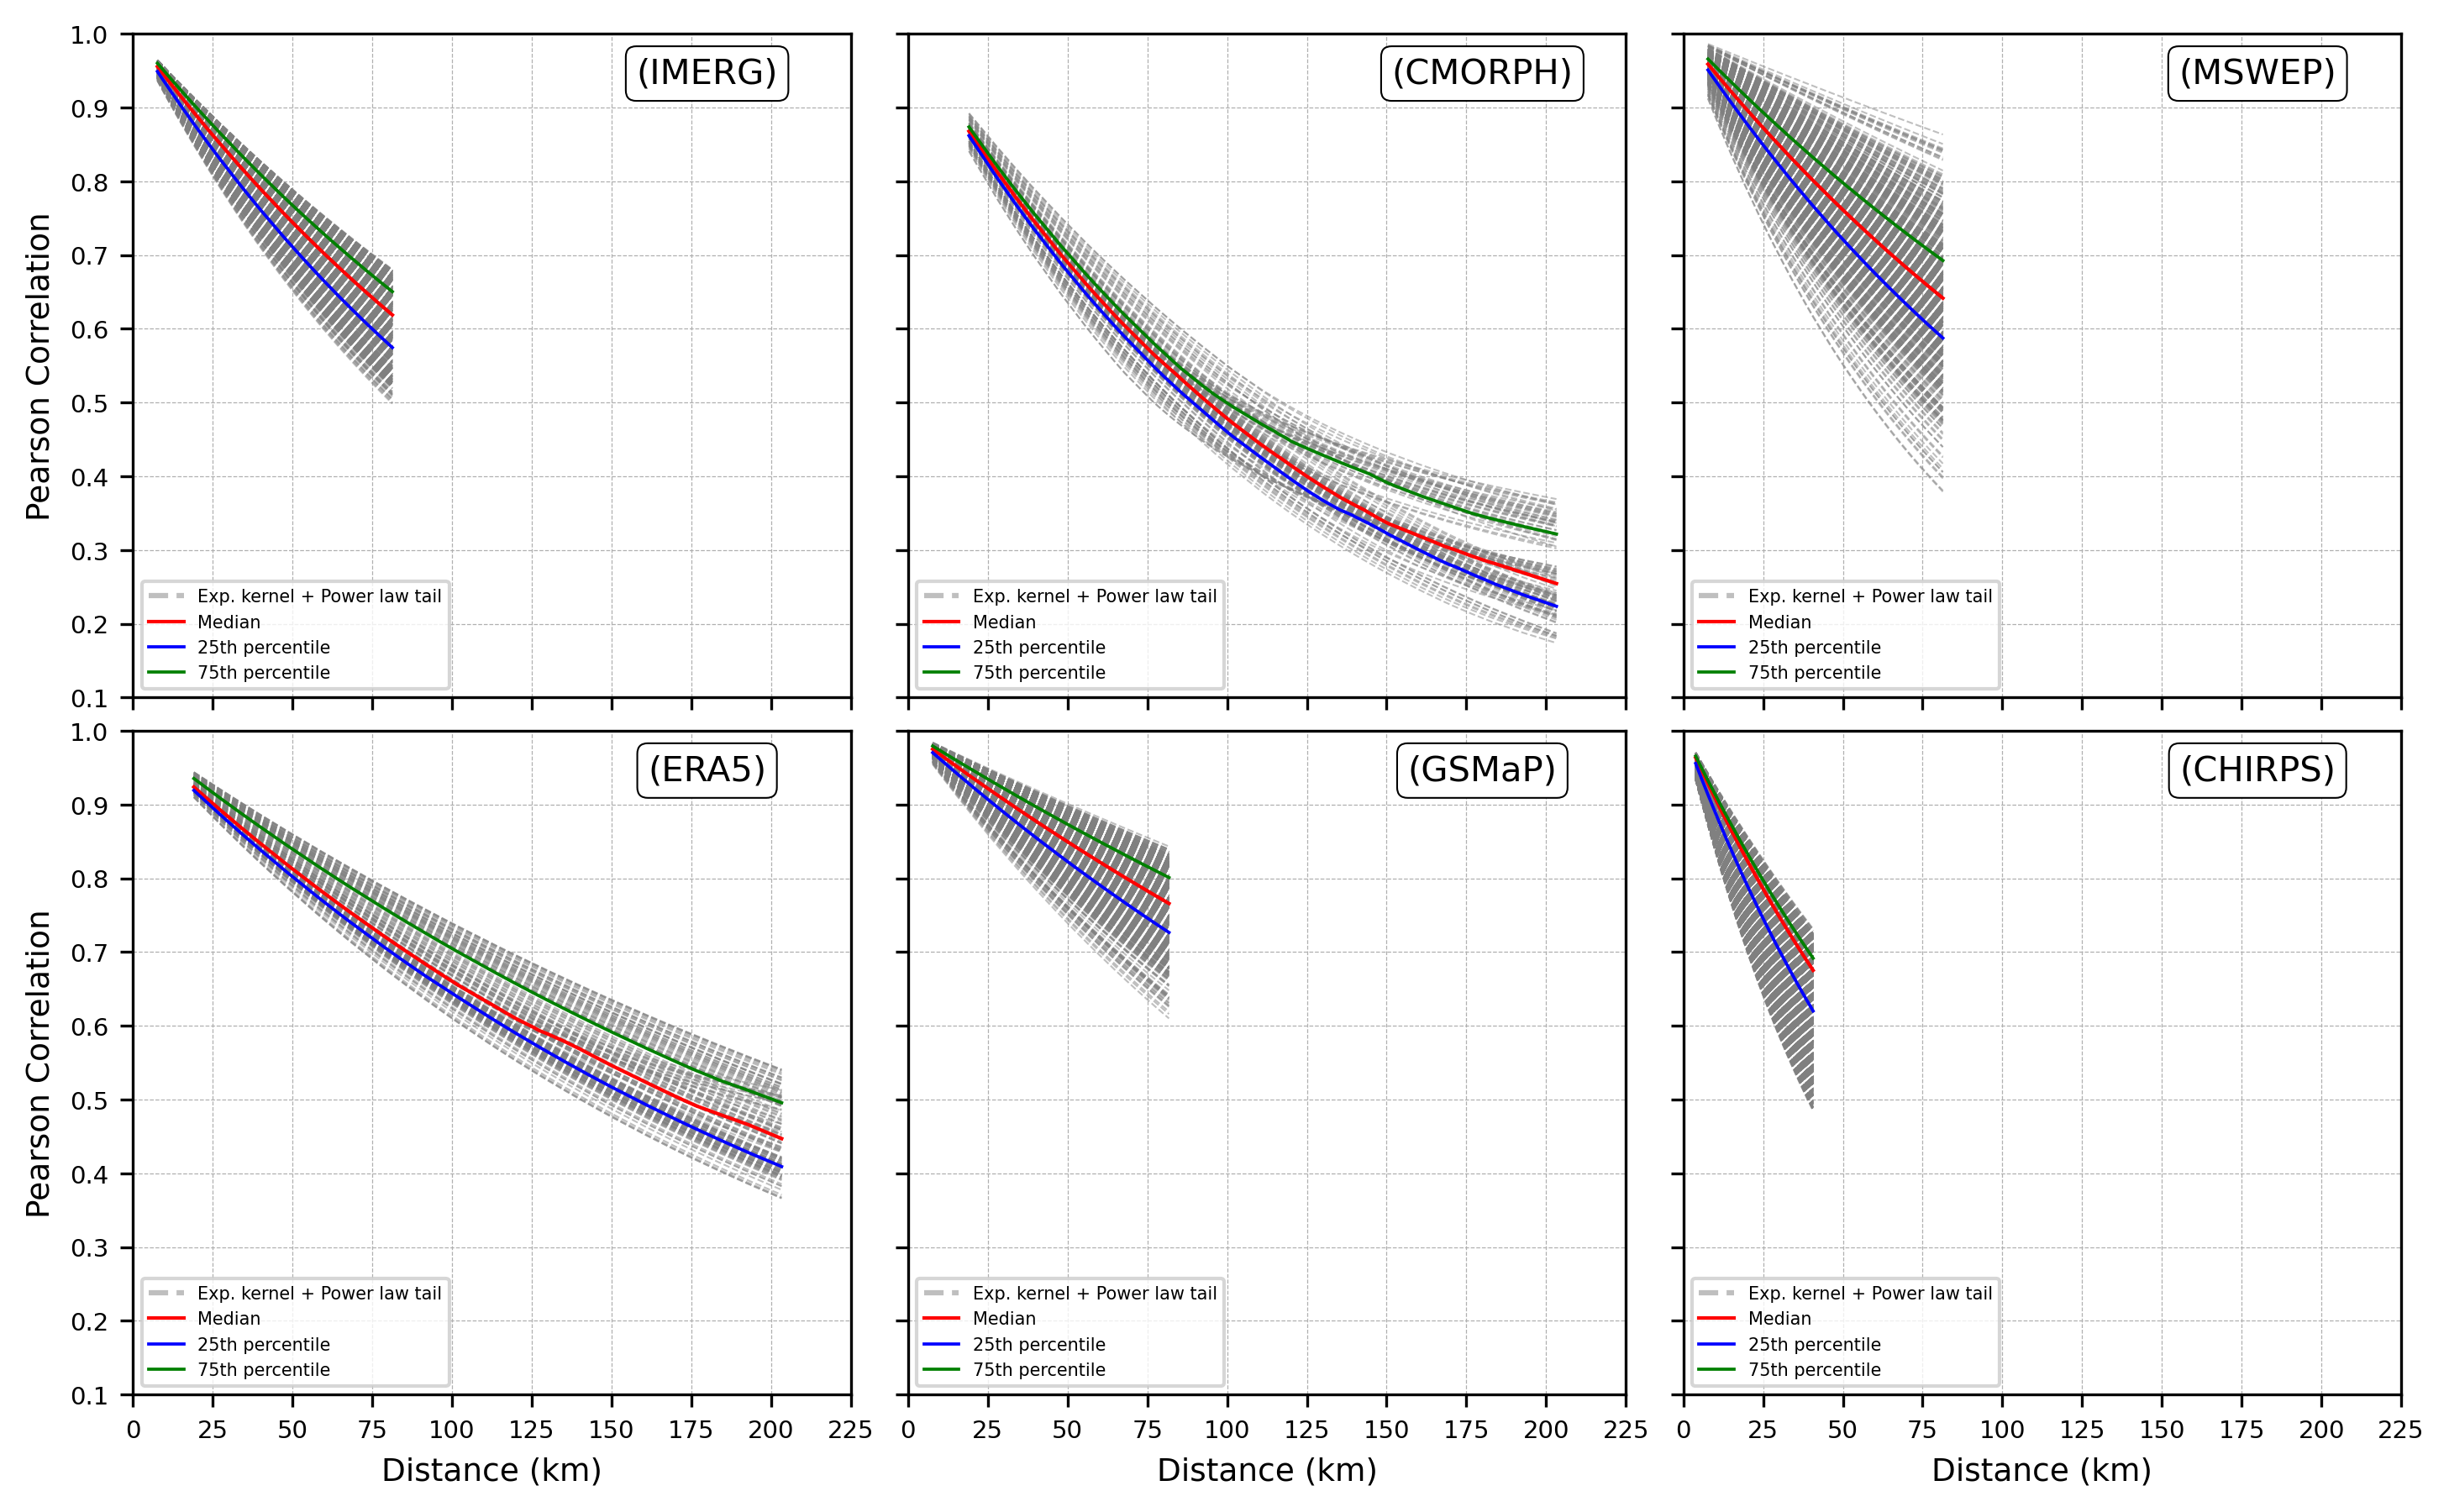

In [ ]:
positions = [(r, c) for r in range(2) for c in range(3)]
# labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
labels = ['(IMERG)','(CMORPH)','(MSWEP)','(ERA5)','(GSMaP)','(CHIRPS)']

fig = plt.figure(figsize=(10, 6), dpi=300)
gs = gridspec.GridSpec(2, 3)

# ==========================================================================================================
axes = {}
pos = 0
for pos, (nrow, ncol) in enumerate(positions):
    
    ax = fig.add_subplot(gs[nrow, ncol])

    if ncol == 1 or ncol ==2:
        ax.set_yticklabels([])

    if nrow == 0:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Distance (km)',fontsize=9)

    if ncol == 0:
        ax.set_ylabel('Pearson Correlation',fontsize=9)

    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.grid(linewidth=0.3, linestyle='--')

    ax.text(0.8, 0.94, labels[pos], 
        fontsize=10, ha='center', va='center',
        transform=ax.transAxes, zorder=20,
        bbox=dict(boxstyle="round,pad=0.3",  
            facecolor="white", 
            alpha=1,
            edgecolor="black",
            linewidth=0.5))

    axes[(nrow, ncol)] = ax

# ==========================================================================================================
axes[(0, 0)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(IMERG_3)):
    y_vals = DOWN_raw.epl_fun(IMERG_dist_3, IMERG_3['epsilon'].iloc[nn], IMERG_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 0)].plot(IMERG_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

IMERG_curvas3 = np.array(todas_las_curvas)

median = np.median(IMERG_curvas3, axis=0)
p25 = np.percentile(IMERG_curvas3, 25, axis=0)
p75 = np.percentile(IMERG_curvas3, 75, axis=0)

axes[(0, 0)].plot(IMERG_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 0)].plot(IMERG_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 0)].plot(IMERG_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 0)].set_xlim(0,225)
axes[(0, 0)].set_ylim(0.1,1)
axes[(0, 0)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(0, 1)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(CMORPH_3)):
    y_vals = DOWN_raw.epl_fun(CMORPH_dist_3, CMORPH_3['epsilon'].iloc[nn], CMORPH_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 1)].plot(CMORPH_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

CMORPH_curvas3 = np.array(todas_las_curvas)

median = np.median(CMORPH_curvas3, axis=0)
p25 = np.percentile(CMORPH_curvas3, 25, axis=0)
p75 = np.percentile(CMORPH_curvas3, 75, axis=0)

axes[(0, 1)].plot(CMORPH_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 1)].plot(CMORPH_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 1)].plot(CMORPH_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 1)].set_xlim(0,225)
axes[(0, 1)].set_ylim(0.1,1)
axes[(0, 1)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(0, 2)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(MSWEP_3)):
    y_vals = DOWN_raw.epl_fun(MSWEP_dist_3, MSWEP_3['epsilon'].iloc[nn], MSWEP_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(0, 2)].plot(MSWEP_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

MSWEP_curvas3 = np.array(todas_las_curvas)

median = np.median(MSWEP_curvas3, axis=0)
p25 = np.percentile(MSWEP_curvas3, 25, axis=0)
p75 = np.percentile(MSWEP_curvas3, 75, axis=0)

axes[(0, 2)].plot(MSWEP_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(0, 2)].plot(MSWEP_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(0, 2)].plot(MSWEP_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(0, 2)].set_xlim(0,225)
axes[(0, 2)].set_ylim(0.1,1)
axes[(0, 2)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 0)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(ERA5_3)):
    y_vals = DOWN_raw.epl_fun(ERA5_dist_3, ERA5_3['epsilon'].iloc[nn], ERA5_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 0)].plot(ERA5_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

ERA5_curvas3 = np.array(todas_las_curvas)

median = np.median(ERA5_curvas3, axis=0)
p25 = np.percentile(ERA5_curvas3, 25, axis=0)
p75 = np.percentile(ERA5_curvas3, 75, axis=0)

axes[(1, 0)].plot(ERA5_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 0)].plot(ERA5_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 0)].plot(ERA5_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 0)].set_xlim(0,225)
axes[(1, 0)].set_ylim(0.1,1)
axes[(1, 0)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 1)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(GSMaP_3)):
    y_vals = DOWN_raw.epl_fun(GSMaP_dist_3, GSMaP_3['epsilon'].iloc[nn], GSMaP_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 1)].plot(GSMaP_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

GSMaP_curvas3 = np.array(todas_las_curvas)

median = np.median(GSMaP_curvas3, axis=0)
p25 = np.percentile(GSMaP_curvas3, 25, axis=0)
p75 = np.percentile(GSMaP_curvas3, 75, axis=0)

axes[(1, 1)].plot(GSMaP_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 1)].plot(GSMaP_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 1)].plot(GSMaP_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 1)].set_xlim(0,225)
axes[(1, 1)].set_ylim(0.1,1)
axes[(1, 1)].legend(fontsize=5,loc=3)

# ==========================================================================================================
axes[(1, 2)].plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(CHIRPS_3)):
    y_vals = DOWN_raw.epl_fun(CHIRPS_dist_3, CHIRPS_3['epsilon'].iloc[nn], CHIRPS_3['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    axes[(1, 2)].plot(CHIRPS_dist_3, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

CHIRPS_curvas3 = np.array(todas_las_curvas)

median = np.median(CHIRPS_curvas3, axis=0)
p25 = np.percentile(CHIRPS_curvas3, 25, axis=0)
p75 = np.percentile(CHIRPS_curvas3, 75, axis=0)

axes[(1, 2)].plot(CHIRPS_dist_3, median, linewidth=1, linestyle='-', color='red', label='Median')
axes[(1, 2)].plot(CHIRPS_dist_3, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
axes[(1, 2)].plot(CHIRPS_dist_3, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

axes[(1, 2)].set_xlim(0,225)
axes[(1, 2)].set_ylim(0.1,1)
axes[(1, 2)].legend(fontsize=5,loc=3)

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.08, hspace=0.05)

salida = os.path.join('..','..','figures','autocorr',f'{region}_autocorr_Npix_3_mar_{method}.png')
print(f'Export figure to: {salida}')
# plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

In [ ]:
colors = ['royalblue','r', 'g', 'c', 'y', 'purple', 'orange', 'cyan']

Export figure to: ../../figures/autocorr/autocorr_Npix_2_3_mar_pearson_10km.png


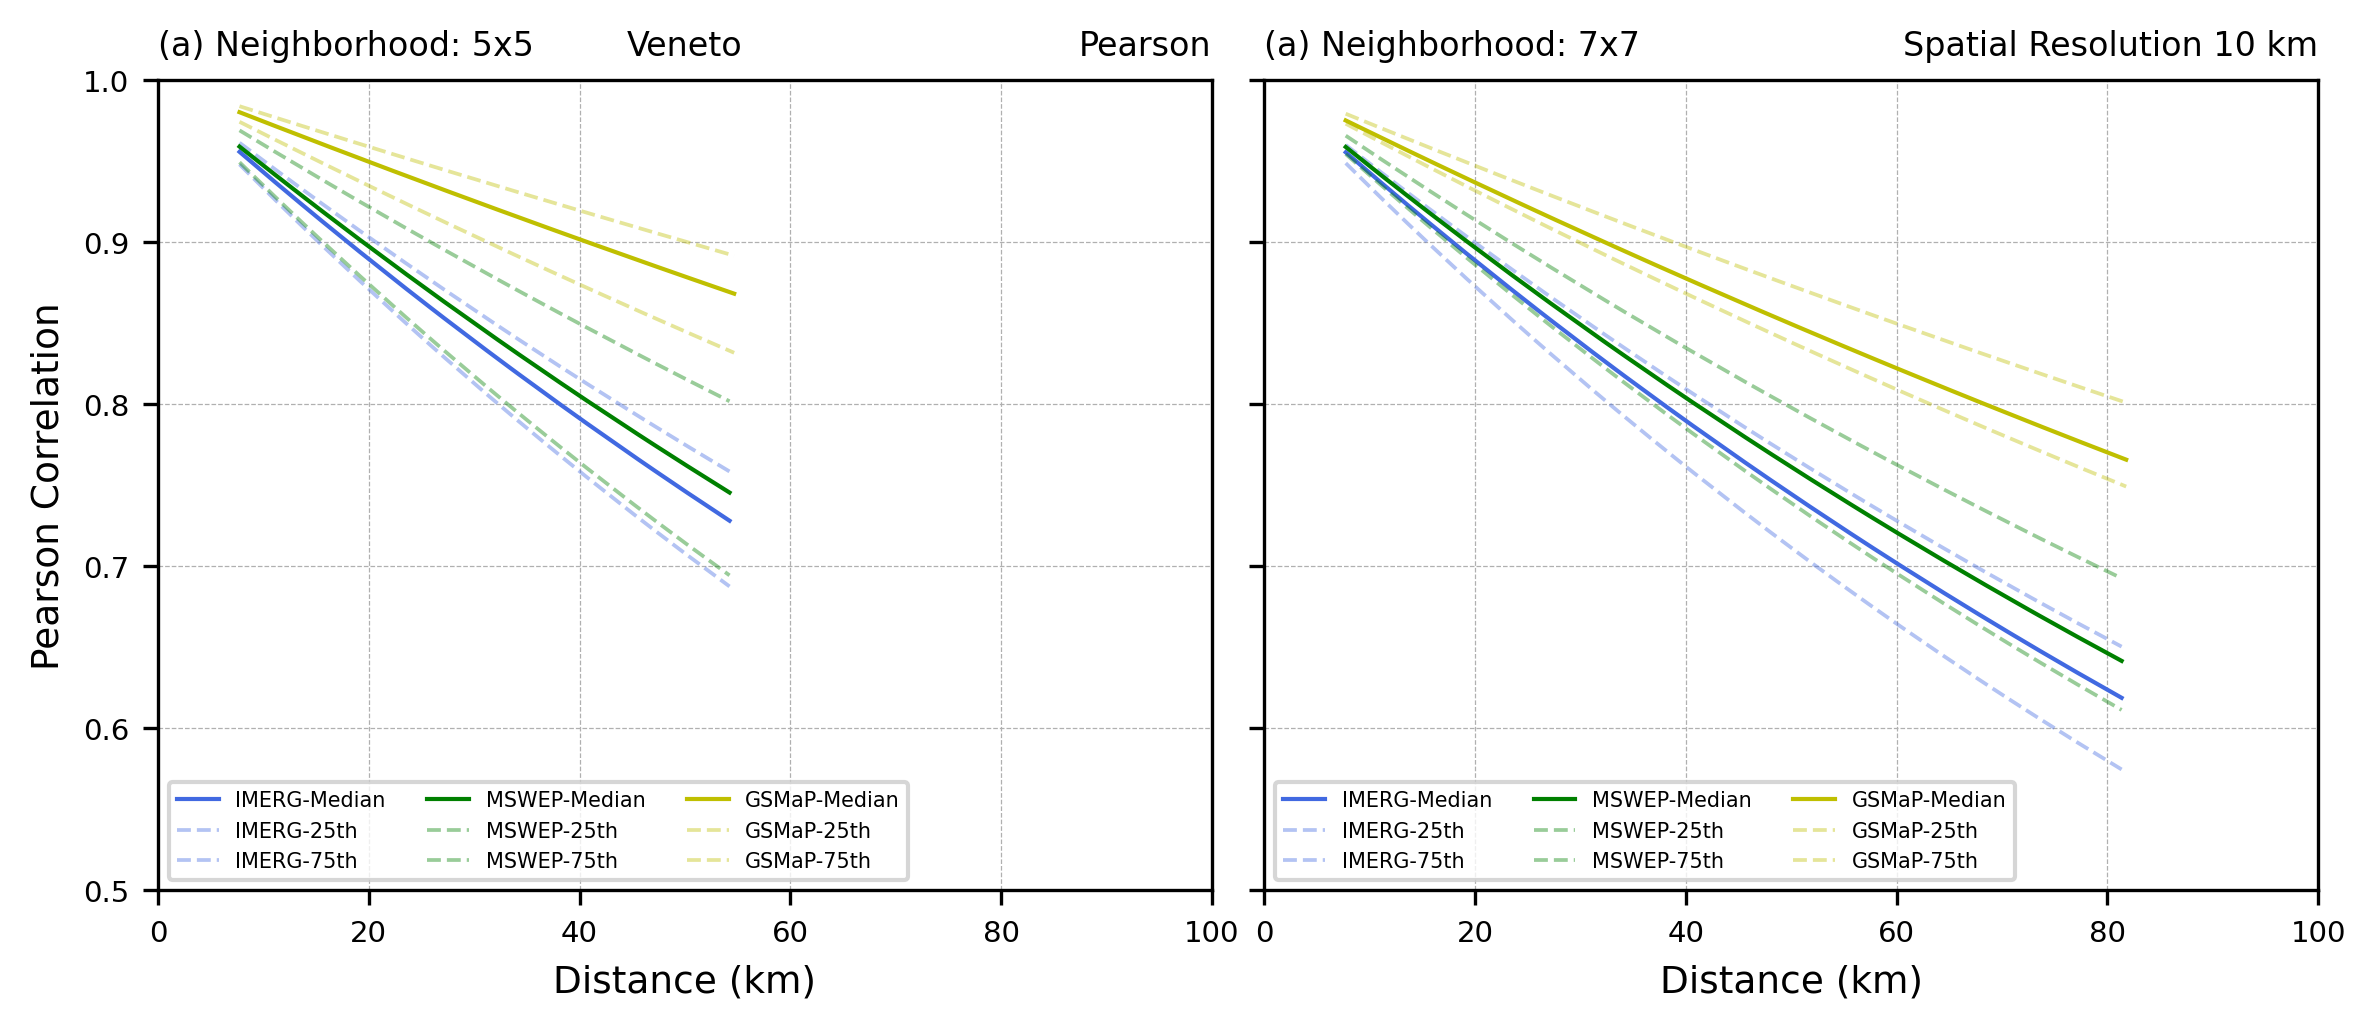

In [ ]:
fig = plt.figure(figsize=(8, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 0])

ax1.plot(IMERG_dist_2, np.median(IMERG_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[0], label='IMERG-Median')
ax1.plot(IMERG_dist_2, np.percentile(IMERG_curvas2, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[0], alpha=0.4, label='IMERG-25th')
ax1.plot(IMERG_dist_2, np.percentile(IMERG_curvas2, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[0], alpha=0.4, label='IMERG-75th')

ax1.plot(MSWEP_dist_2, np.median(MSWEP_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[2], label='MSWEP-Median')
ax1.plot(MSWEP_dist_2, np.percentile(MSWEP_curvas2, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[2], alpha=0.4, label='MSWEP-25th')
ax1.plot(MSWEP_dist_2, np.percentile(MSWEP_curvas2, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[2], alpha=0.4, label='MSWEP-75th')

ax1.plot(GSMaP_dist_2, np.median(GSMaP_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[4], label='GSMaP-Median')
ax1.plot(GSMaP_dist_2, np.percentile(GSMaP_curvas2, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[4], alpha=0.4, label='GSMaP-25th')
ax1.plot(GSMaP_dist_2, np.percentile(GSMaP_curvas2, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[4], alpha=0.4, label='GSMaP-75th')

ax1.set_xlim(0,100)
ax1.set_ylim(0.5,1)
ax1.legend(fontsize=5,loc=3, ncol=3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_xlabel('Distance (km)',fontsize=9)
ax1.set_ylabel('Pearson Correlation',fontsize=9)

ax1.set_title('(a) Neighborhood: 5x5', fontsize=8, loc='left')
ax1.set_title('Veneto', fontsize=8, loc='center')
ax1.set_title('Pearson', fontsize=8, loc='right')

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 1])

ax1.plot(IMERG_dist_3, np.median(IMERG_curvas3, axis=0), linewidth=1, linestyle='-', color=colors[0], label='IMERG-Median')
ax1.plot(IMERG_dist_3, np.percentile(IMERG_curvas3, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[0], alpha=0.4, label='IMERG-25th')
ax1.plot(IMERG_dist_3, np.percentile(IMERG_curvas3, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[0], alpha=0.4, label='IMERG-75th')

ax1.plot(MSWEP_dist_3, np.median(MSWEP_curvas3, axis=0), linewidth=1, linestyle='-', color=colors[2], label='MSWEP-Median')
ax1.plot(MSWEP_dist_3, np.percentile(MSWEP_curvas3, 35, axis=0), linewidth=0.9, linestyle='--', color=colors[2], alpha=0.4, label='MSWEP-25th')
ax1.plot(MSWEP_dist_3, np.percentile(MSWEP_curvas3, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[2], alpha=0.4, label='MSWEP-75th')

ax1.plot(GSMaP_dist_3, np.median(GSMaP_curvas3, axis=0), linewidth=1, linestyle='-', color=colors[4], label='GSMaP-Median')
ax1.plot(GSMaP_dist_3, np.percentile(GSMaP_curvas3, 35, axis=0), linewidth=0.9, linestyle='--', color=colors[4], alpha=0.4, label='GSMaP-25th')
ax1.plot(GSMaP_dist_3, np.percentile(GSMaP_curvas3, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[4], alpha=0.4, label='GSMaP-75th')

ax1.set_xlim(0,100)
ax1.set_ylim(0.5,1)
ax1.legend(fontsize=5,loc=3, ncol=3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_yticklabels([])
ax1.set_xlabel('Distance (km)',fontsize=9)

ax1.set_title('(a) Neighborhood: 7x7', fontsize=8, loc='left')
ax1.set_title('Spatial Resolution 10 km', fontsize=8, loc='right')

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.05)

Export figure to: ../../figures/autocorr/autocorr_Npix_2_3_mar_pearson_25km.png


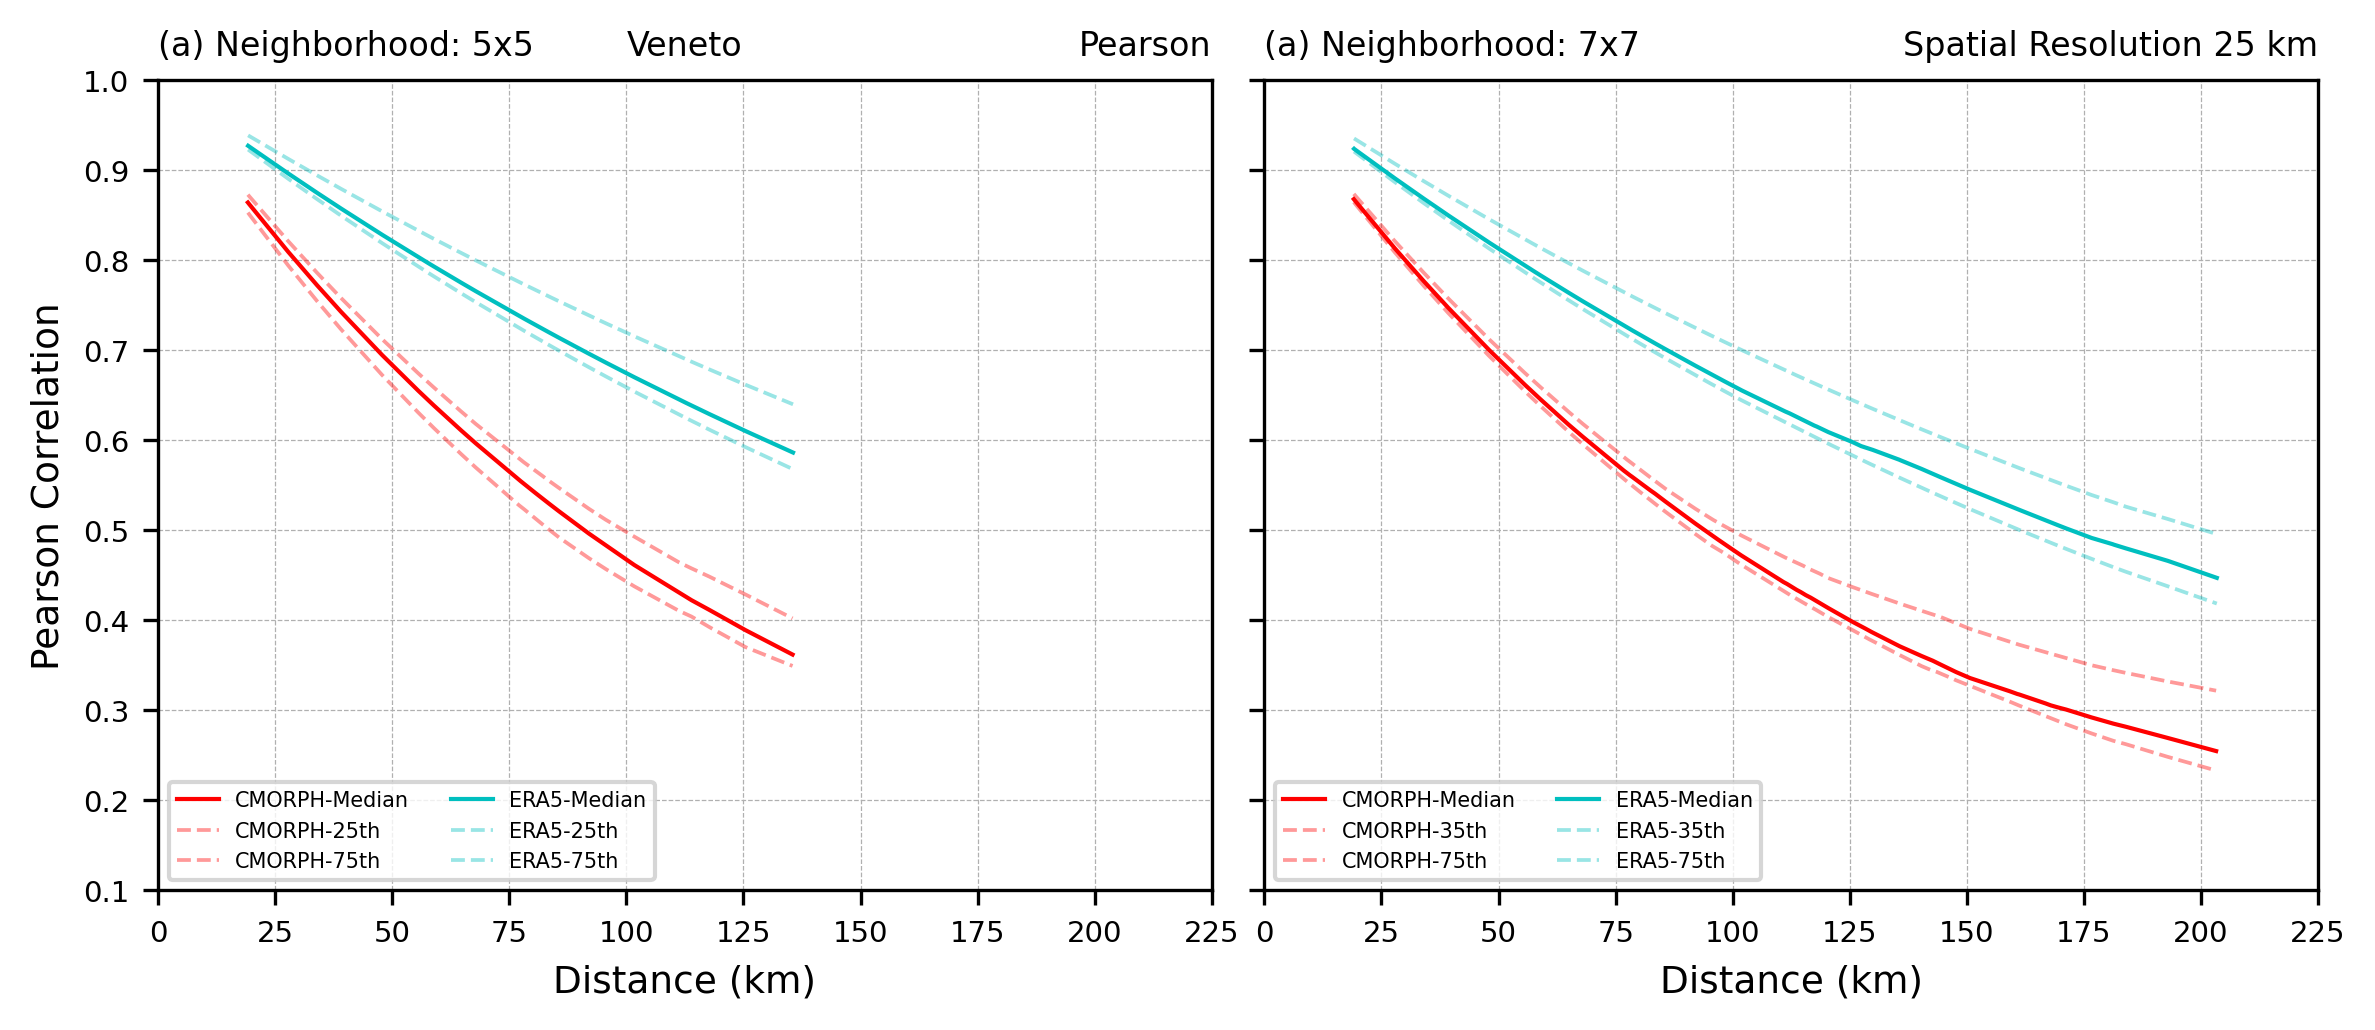

In [ ]:
fig = plt.figure(figsize=(8, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 0])

ax1.plot(CMORPH_dist_2, np.median(CMORPH_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[1], label='CMORPH-Median')
ax1.plot(CMORPH_dist_2, np.percentile(CMORPH_curvas2, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[1], alpha=0.4, label='CMORPH-25th')
ax1.plot(CMORPH_dist_2, np.percentile(CMORPH_curvas2, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[1], alpha=0.4, label='CMORPH-75th')

ax1.plot(ERA5_dist_2, np.median(ERA5_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[3], label='ERA5-Median')
ax1.plot(ERA5_dist_2, np.percentile(ERA5_curvas2, 25, axis=0), linewidth=0.9, linestyle='--', color=colors[3], alpha=0.4, label='ERA5-25th')
ax1.plot(ERA5_dist_2, np.percentile(ERA5_curvas2, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[3], alpha=0.4, label='ERA5-75th')

ax1.set_xlim(0,225)
ax1.set_ylim(0.1,1)
ax1.legend(fontsize=5,loc=3, ncol=2)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_xlabel('Distance (km)',fontsize=9)
ax1.set_ylabel('Pearson Correlation',fontsize=9)

ax1.set_title('(a) Neighborhood: 5x5', fontsize=8, loc='left')
ax1.set_title('Veneto', fontsize=8, loc='center')
ax1.set_title('Pearson', fontsize=8, loc='right')

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 1])

ax1.plot(CMORPH_dist_3, np.median(CMORPH_curvas3, axis=0), linewidth=1, linestyle='-', color=colors[1], label='CMORPH-Median')
ax1.plot(CMORPH_dist_3, np.percentile(CMORPH_curvas3, 35, axis=0), linewidth=0.9, linestyle='--', color=colors[1], alpha=0.4, label='CMORPH-35th')
ax1.plot(CMORPH_dist_3, np.percentile(CMORPH_curvas3, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[1], alpha=0.4, label='CMORPH-75th')

ax1.plot(ERA5_dist_3, np.median(ERA5_curvas3, axis=0), linewidth=1, linestyle='-', color=colors[3], label='ERA5-Median')
ax1.plot(ERA5_dist_3, np.percentile(ERA5_curvas3, 35, axis=0), linewidth=0.9, linestyle='--', color=colors[3], alpha=0.4, label='ERA5-35th')
ax1.plot(ERA5_dist_3, np.percentile(ERA5_curvas3, 75, axis=0), linewidth=0.9, linestyle='--', color=colors[3], alpha=0.4, label='ERA5-75th')

ax1.set_xlim(0,225)
ax1.set_ylim(0.1,1)
ax1.legend(fontsize=5,loc=3, ncol=2)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_yticklabels([])
ax1.set_xlabel('Distance (km)',fontsize=9)

ax1.set_title('(a) Neighborhood: 7x7', fontsize=8, loc='left')
ax1.set_title('Spatial Resolution 25 km', fontsize=8, loc='right')

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.05)

Export figure to: ../../figures/autocorr/autocorr_Npix_2_3_mar_pearson_all.png


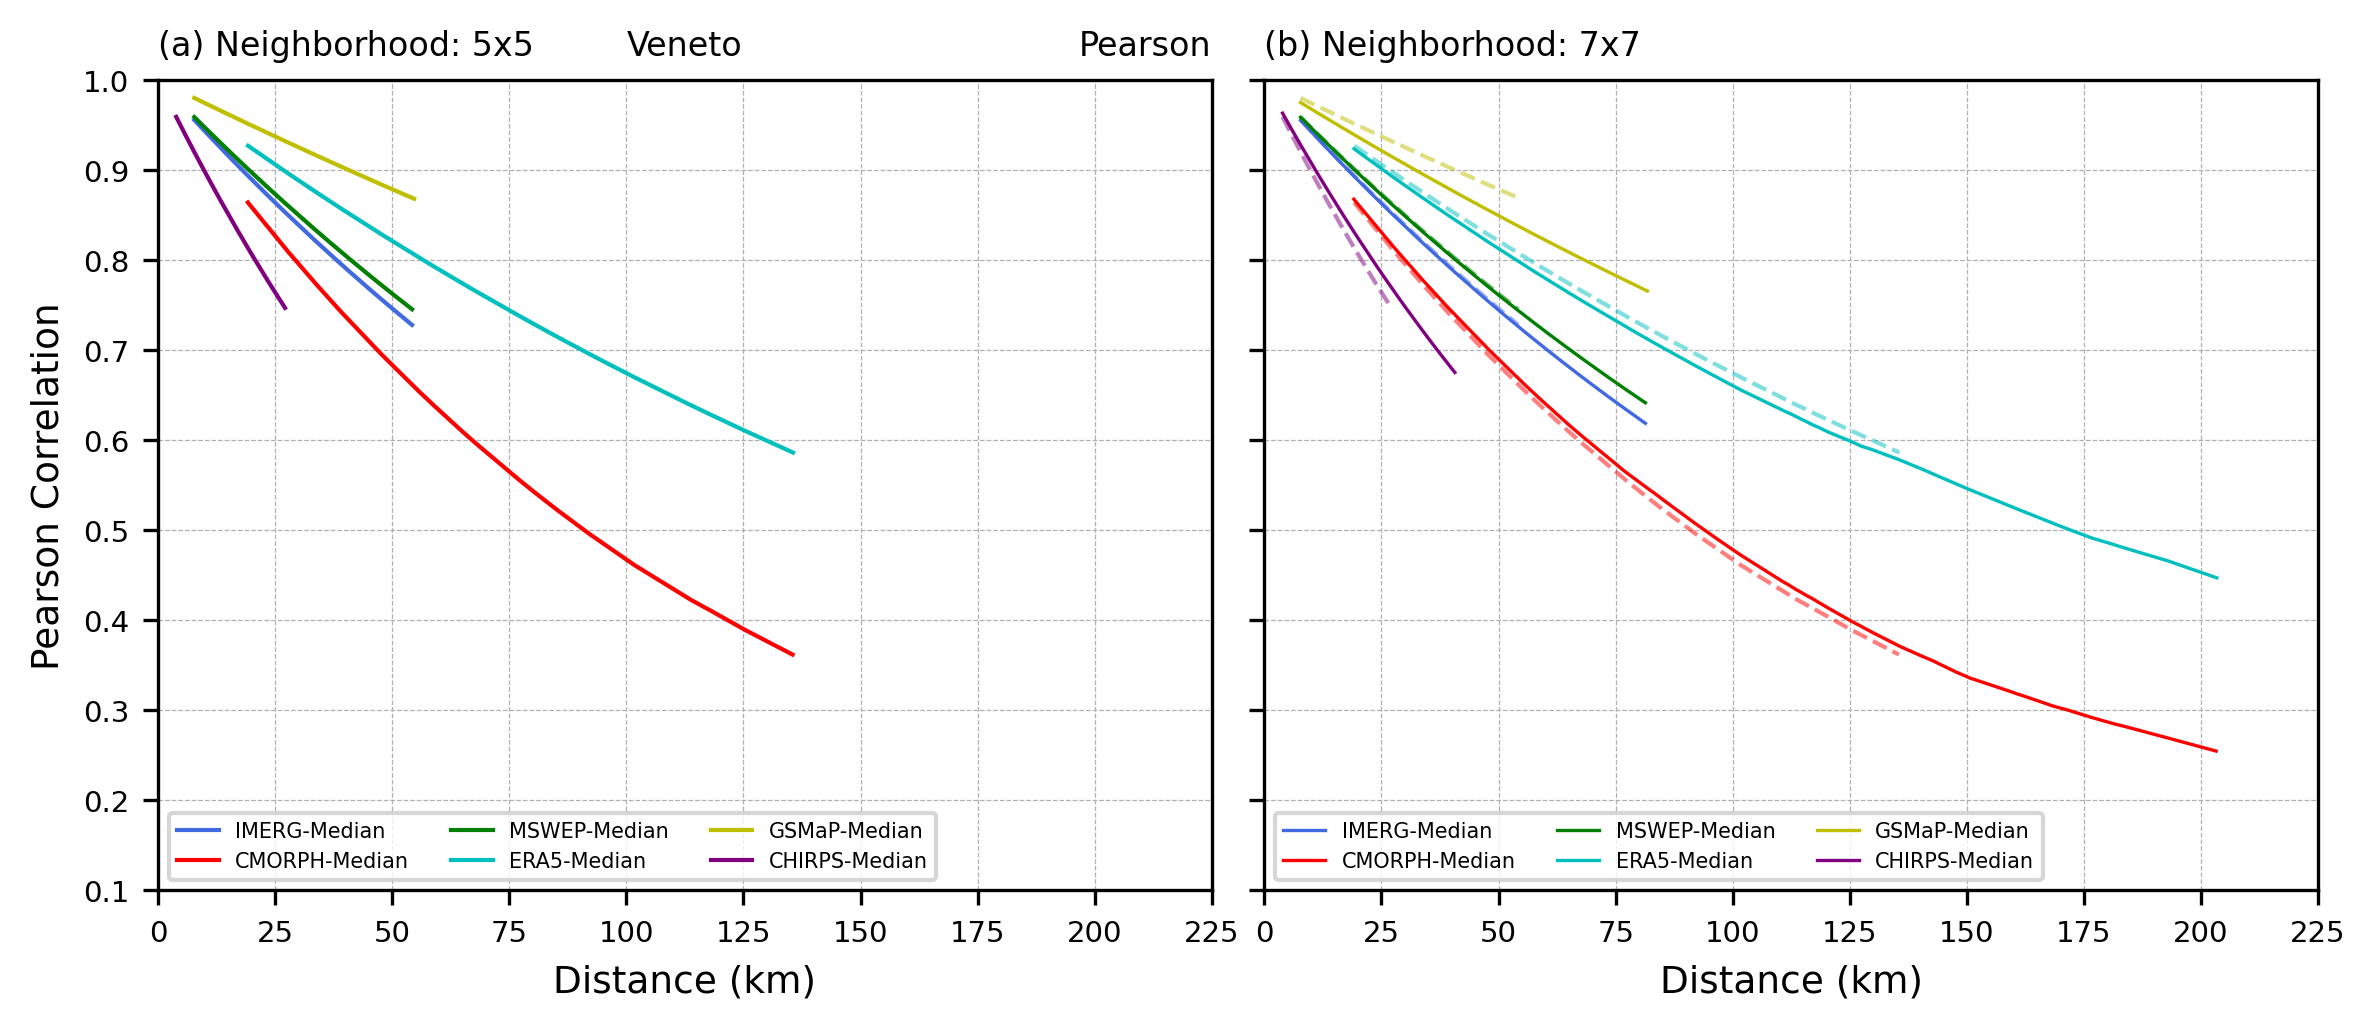

In [ ]:
fig = plt.figure(figsize=(8, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 0])

ax1.plot(IMERG_dist_2, np.median(IMERG_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[0], label='IMERG-Median')
ax1.plot(CMORPH_dist_2, np.median(CMORPH_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[1], label='CMORPH-Median')
ax1.plot(MSWEP_dist_2, np.median(MSWEP_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[2], label='MSWEP-Median')
ax1.plot(ERA5_dist_2, np.median(ERA5_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[3], label='ERA5-Median')
ax1.plot(GSMaP_dist_2, np.median(GSMaP_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[4], label='GSMaP-Median')
ax1.plot(CHIRPS_dist_2, np.median(CHIRPS_curvas2, axis=0), linewidth=1, linestyle='-', color=colors[5], label='CHIRPS-Median')

ax1.set_xlim(0,225)
ax1.set_ylim(0.1,1)
ax1.legend(fontsize=5,loc=3, ncol=3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_xlabel('Distance (km)',fontsize=9)
ax1.set_ylabel('Pearson Correlation',fontsize=9)

ax1.set_title('(a) Neighborhood: 5x5', fontsize=8, loc='left')
ax1.set_title('Veneto', fontsize=8, loc='center')
ax1.set_title('Pearson', fontsize=8, loc='right')

# ==========================================================================================================
ax1 = plt.subplot(gs[0, 1])

ax1.plot(IMERG_dist_2, np.median(IMERG_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[0], alpha=0.5)
ax1.plot(CMORPH_dist_2, np.median(CMORPH_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[1], alpha=0.5)
ax1.plot(MSWEP_dist_2, np.median(MSWEP_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[2], alpha=0.5)
ax1.plot(ERA5_dist_2, np.median(ERA5_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[3], alpha=0.5)
ax1.plot(GSMaP_dist_2, np.median(GSMaP_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[4], alpha=0.5)
ax1.plot(CHIRPS_dist_2, np.median(CHIRPS_curvas2, axis=0), linewidth=1, linestyle='--', color=colors[5], alpha=0.5)

ax1.plot(IMERG_dist_3, np.median(IMERG_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[0], label='IMERG-Median')
ax1.plot(CMORPH_dist_3, np.median(CMORPH_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[1], label='CMORPH-Median')
ax1.plot(MSWEP_dist_3, np.median(MSWEP_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[2], label='MSWEP-Median')
ax1.plot(ERA5_dist_3, np.median(ERA5_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[3], label='ERA5-Median')
ax1.plot(GSMaP_dist_3, np.median(GSMaP_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[4], label='GSMaP-Median')
ax1.plot(CHIRPS_dist_3, np.median(CHIRPS_curvas3, axis=0), linewidth=0.8, linestyle='-', color=colors[5], label='CHIRPS-Median')

ax1.set_xlim(0,225)
ax1.set_ylim(0.1,1)
ax1.legend(fontsize=5,loc=3, ncol=3)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=7)

ax1.set_yticklabels([])
ax1.set_xlabel('Distance (km)',fontsize=9)

ax1.set_title('(b) Neighborhood: 7x7', fontsize=8, loc='left')

# ==========================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.05)

salida = os.path.join('..','..','figures','autocorr',f'{region}_autocorr_Npix_2_3_mar_{method}_all.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)